In [1]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.special import ellipk, ellipe
from numpy import vectorize

In [2]:
# Profiles
# n = 0:   NIS
# n = 3:   NFW
# n = 3.5: sNFW
# n = 4:   Hernquist

# Convergence (Simplified)
def Convergence_sim(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(1/(x**2 - 1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(1/(x**2 - 1))*(1 - np.arccos(1/x)/arg)
            
    #sNFW
    if n == 3.5:
        arg = (1 - x)/(1 + x)
        if x == 1:
            return k0*9*np.pi/(128*np.sqrt(2))
        if x != 1:
            return k0*(((3 + x)*ellipk(arg) - 4*ellipe(arg))/(2*(1 - x)**2*(1 + x)**(3/2)))
            
        
    #Hernquist
    if n == 4:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return 4*amp/15
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccosh(1/x) - 3)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccos(1/x) - 3)

    #NIS
    if n == 0:
        return k0*np.sqrt(np.pi)/np.sqrt(1 + x**2)


# Deflection angle (Simplified)
def DAngle_sim(x, n, k0):
    """
    x: dimensionless radius (position)
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 - np.log(2))
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccos(1/np.abs(x))/arg)
    #sNFW
    if n == 3.5:
        amp = 2*k0
        arg = (1 - np.abs(x))/(1 + np.abs(x))
        if x == 0:
            return 0.
        if np.abs(x) == 1:
            return amp*(1 - 3*np.pi/(8*np.sqrt(2)))
        if np.abs(x) > 0 and np.abs(x) != 1:
            return (amp/x)*(((ellipe(arg) - np.abs(x)*ellipk(arg))/(np.sqrt(1 + np.abs(x))*(np.abs(x) - 1))) + 1)
    
    #Hernquist
    if n == 4:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp/3
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1. - x**2)
            return (amp*x/(x**2 - 1))*(1 - np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp*x/(x**2 - 1))*(1 - np.arccos(1/np.abs(x))/arg)

    #NIS
    if n == 0:
        if x == 0:
            return 0
        else:
            return 2*np.sqrt(np.pi)*k0*(np.sqrt(1 + x**2) - 1)/x

# Shear (Simplified)
def Shear_sim(x, n, k0):
    """
    x >= 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    if x == 0 and n == 0:
        return 0
    if x == 0 and n != 0:
        return k0*gamma(n - 1)/(2*np.sqrt(np.pi))
    if x > 0:
        return DAngle_sim(x, n, k0)/x - Convergence_sim(x, n, k0)

# Magnification (Simplified)
def Magnification(x, n, k0):
    if x == 0 and n == 0:
        return 1/(1 - k0*np.sqrt(np.pi))**2
    if x == 0 and n != 0:
        return 0 
    if x > 0:
        return 1/((1 - Convergence_sim(x, n, k0))**2 - Shear_sim(x, n, k0)**2)
        
# Vectorized functions
c_sim = vectorize(Convergence_sim, otypes=[float], cache = True)
da_sim = vectorize(DAngle_sim, otypes=[float], cache = True)
s_sim = vectorize(Shear_sim, otypes=[float], cache = True)
magnification = vectorize(Magnification, otypes=[float], cache = True)

In [3]:
# Equation for fincding the radial critical curve: RCC = 0
def RCC(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    return 1 + DAngle_sim(x, n, k0)/x - 2*Convergence_sim(x, n, k0)

# Equation for fincding the tangential critical curve: TCC = 0
def TCC(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    return 1 - DAngle_sim(x, n, k0)/x
    
# Vectorized functions
tcc = vectorize(TCC, otypes=[float], cache = True)
rcc = vectorize(RCC, otypes=[float], cache = True)

In [4]:
def CCSolve(cri, crf, cti, ctf, N, RN, n, k0):
    """
    Here, we follow a similar process to the described in our paper (Sec. 5.2) for solving the lens equation. 
    
    For example, if we want to find the tangential critical curve, we take the domain (cti, ctf) and construct a one-dimensional grid
    with N nodes. Then, we evaluate the function TCC for that grid, such that the node for wich TCC is closest to zero corresponds to
    the tagential critical curve. Here, we can follow a refinement process which we repeat RN times. For RN = 1 we need N to be a
    relatively large number. However, if RN > 1, we can use a smaller N, and considering that the computed critical curve (approximately) 
    is the node x_i, the refinament process take the interval (x_(i-1), x_(i+1)) and construct the new grid, for which we repeat the 
    process. For the radial critical curve we follow the same process.
    
    (cri, crf): limits (they are both positive) within which we consider the critical radial curve is lolated
    (cti, ctf): limits (they are both positive) within which we consider the critical tangental curve is lolated
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: characteristic convergence
    """
    
    dx1 = np.abs(ctf - cti)/N
    dx2 = np.abs(crf - cri)/N
    x1 = np.linspace(cti, ctf, N)
    x2 = np.linspace(cri, crf, N)
    
    for i in range(RN):
        d1 = np.abs(tcc(x1, n, k0))
        d2 = np.abs(rcc(x2, n, k0))
        ind1 = np.where(d1 == np.amin(d1))[0][0]
        ind2 = np.where(d2 == np.amin(d2))[0][0]
        
        tan = x1[ind1]
        rad = x2[ind2]

        if tan - dx1 < 0:
            x1 = np.linspace(tan, tan + dx1, N)
        else:
            x1 = np.linspace(tan - dx1, tan + dx1, N)
        if rad - dx2 < 0:
            x2 = np.linspace(rad, rad + dx2, N)
        else:
            x2 = np.linspace(rad - dx2, rad + dx2, N)
            
        dx1 = 2*dx1/N
        dx2 = 2*dx2/N

        if np.abs(tcc(tan, n, k0)) <= 1e-15 and np.abs(rcc(rad, n, k0)) <= 1e-15:
            break

    return rad, tan

In [5]:
def LESolve1(y, xi, xf, N, RN, n, k0):
    """
    Given a source with radial position y, this function solves the lens equation considering that only one solution exists, and it is 
    located within the interval (xi, xf). We follow the process described in our paper (Sec. 5.2).

    Within the domain (xi, xf) we construct a one-dimensional grid with N nodes. Then, we evaluate the lens equation for that grid, 
    such that the node for wich x - deflection_angle is closest to be equal to y, is the potential solution to the lens equation. 
    Here, we can follow a refinement process which we repeat RN times. For RN = 1 we need N to be a relatively large number.
    However, if RN > 1, we can use a smaller N, and considering that the computed solution (approximately) is the node x_i, the 
    refinament process take the interval (x_(i-1), x_(i+1)) and construct the new grid, for which we repeat the process.

    y > yc2 (radial caustic curve): source radial position
    (xi, xf): limits (they are both positive) within which we consider the image is lolated. Here, xi >= xb. 
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: characteristic convergence
    """

    dx = np.abs(xf - xi)/N
    x = np.linspace(xi, xf, N)
    for i in range(RN):
        d = np.abs(y - x + da_sim(x, n, k0))
        ind = np.where(d == np.amin(d))[0][0]

        xb = x[ind]
        
        x = np.linspace(xb - dx, xb + dx, N)
        dx = 2*dx/N
        if np.abs(y - xb + da_sim(xb, n, k0))<= 1e-15 :
            break

    return xb

def LESolve3(y, xc1, xc2, xb, N, RN, n, k0):

    """
    Given a source with radial position 0 < y < yc2, this function solves the lens equation finding the three possible images. These
    images are formed at (-xc1, -xc2), (-xc2, 0), and (xc1, xb). Recall that the minus sign represents the images having azimuthal 
    difference of pi radians with respect to the source. We follow the process described in our paper (Sec. 5.2).

    For example, if we wan to find the image formed within (xc1, xb), we take this domain and construct a one-dimensional grid with N nodes.
    Then, we evaluate the lens equation for that grid, such that the node for wich x - deflection_angle is closest to be equal to y, is 
    the potential solution to the lens equation. Here, we can follow a refinement process which we repeat RN times. For RN = 1 we need N to 
    be a relatively large number. However, if RN > 1, we can use a smaller N, and considering that the computed solution (approximately) is 
    the node x_i, the  refinament process take the interval (x_(i-1), x_(i+1)) and construct the new grid, for which we repeat the process.
    We follow the same process for the other two images.

    0 < y < yc2 (radial caustic curve): source radial position
    xc1 > 0: tangential critical curve
    xc2 > 0: radial critical curve
    xb > 0:  boundary within which multiple images can appear
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: characteristic convergence
    """
    
    roots = np.zeros(3)
    dx1 = np.abs(xc2)/N
    dx2 = np.abs(xc1 - xc2)/N
    dx3 = np.abs(xb - xc1)/N
    x1 = np.linspace(-xc2, 0, N)
    x2 = np.linspace(-xc1, -xc2, N)
    x3 = np.linspace(xc1, xb, N)
    for i in range(RN):
        d1 = np.abs(y - x1 + da_sim(x1, n, k0))
        d2 = np.abs(y - x2 + da_sim(x2, n, k0))
        d3 = np.abs(y - x3 + da_sim(x3, n, k0))
        ind1 = np.where(d1 == np.amin(d1))[0][0]
        ind2 = np.where(d2 == np.amin(d2))[0][0]
        ind3 = np.where(d3 == np.amin(d3))[0][0]
        r1 = x1[ind1]
        r2 = x2[ind2]
        r3 = x3[ind3]
        x1 = np.linspace(r1 - dx1, r1 + dx1, N)
        x2 = np.linspace(r2 - dx2, r2 + dx2, N)
        x3 = np.linspace(r3 - dx3, r3 + dx3, N)
        dx1 = 2*dx1/N
        dx2 = 2*dx2/N
        dx3 = 2*dx3/N
        
        roots[1] = r1
        roots[0] = r2
        roots[2] = r3

    return roots

In [6]:
def critical_points(cri, crf, cti, ctf, xb, N, RN, n, k0):
    """
    We start from the larger value, so that we can use its parame
    (cri, crf): initial limits for k0[-1] (they are both positive) within which we consider the critical radial curve is lolated
    (cti, ctf): initial limits for k0[-1] (they are both positive) within which we consider the critical tangental curve is lolated
    xb: initial estimation for k0[-1]
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: list with the different characteristic convergences to evaluate
    """
    
    points = len(k0)

    xc2_list = np.zeros(points)
    xc1_list = np.zeros(points)
    yc2_list = np.zeros(points)
    xb_list  = np.zeros(points)

    for i in range(points):
        xc2, xc1 = CCSolve(cri, crf, cti, ctf, N, RN, n, k0[::-1][i])
        
        yc2 = np.abs(xc2 - da_sim(xc2, n, k0[::-1][i]))
        xb = np.abs(LESolve1(yc2, xc1, xb, N, RN, n, k0[::-1][i]))

        rc = np.abs(RCC(xc2, n, k0[::-1][i]))
        rt = np.abs(TCC(xc1, n, k0[::-1][i]))
        rb = np.abs(xb - da_sim(xb, n, k0[::-1][i]) - yc2)

        
        #Here. we verify that the critial and caustic curves, and xb are correct, within a certain degree.
        if np.any(np.array([rc, rt, rb]) > 1e-6):
                print("Not good enough")
                print(k0[::-1][i], np.array([rc, rt, rb]))
            
        xc2_list[::-1][i] = xc2
        xc1_list[::-1][i] = xc1
        yc2_list[::-1][i] = yc2
        xb_list[::-1][i]  = xb

        # Restart the boundaries
        cri = 1e-10
        crf = 1.2*xc2
        cti = 1e-10
        ctf = 1.2*xc1 
        
    return xc2_list, xc1_list, xb_list, yc2_list



def minvariant(p_eval, xc2, xc1, xb, yc2, N, RN, n, k0):
    """
    Here, we compute the magnification as a function of k0.

    p_eval: number of sources to be considered for each value of k0
    xc2: list of radial critical curves that match k0
    xc1: list of tangential critical curves that match k0
    xb: list of boundaries within which multiple images are form, that match k0
    N: number of nodes 
    RN: how many times we perform the refinement
    n: profile
    k0: list of characteristic convergences
    """
    
    points = len(k0)
    y_red = np.zeros((points, p_eval))
    I = np.zeros((points, p_eval))
    I_min = np.zeros(points)
    I_max = np.zeros(points)
    I_av = np.zeros(points)
    std = np.zeros(points)

    for j in range(points):
        yj = np.linspace(0.01*yc2[j], 0.99*yc2[j], p_eval) # Position of the source inside the radial caustic
        Ij = np.zeros(p_eval) 
        for i in range(p_eval):
            root = LESolve3(yj[i], xc1[j], xc2[j], xb[j], N, RN, n, k0[j]) # We solve the lens equation for each source

            # Here, we evaluate that the images are differente, and satisfy the lens equation 
            if root[0]<root[1]<root[2]:
                error = np.abs((root - da_sim(root, n, k0[j]) - yj[i])/yj[i])

                if np.any(error > 1e-3):
                    print("Not good enough")
                    print(error)
                    
                Ij[i] = np.sum(magnification(np.abs(root), n, k0[j]))
                
            else:
                print("Ups...")
                print(k0[j], yj[i], root)
                break
                
        I_min[j] = np.amin(Ij)
        I_max[j] = np.amax(Ij)
        I_av[j] = np.average(Ij)
        std[j] = np.std(Ij)
        I[j] = Ij
        y_red[j] = yj/yc2[j]

    return I_min, I_max, I_av, std, I, y_red

### NIS

In [7]:
points_nis = 200
k0_max = 1000
points_eval = 10
k0_nis = np.linspace(1, k0_max, points_nis)

n_nis = 0

In [8]:
# Here, we find the initial values, wich are obtained form those of k0_max
crs, cts = CCSolve(5, 300, 100, 5000, 100, 10, n_nis, k0_max)
print("Radial = ", crs)
print("Tangential = ", cts)
print("|RCC| =", np.abs(RCC(crs, n_nis, k0_max))) # Ideally, it should be equal to zero
print("|TCC| =", np.abs(TCC(cts, n_nis, k0_max))) # Ideally, it should be equal to zero

Radial =  59.03275764270343
Tangential =  3543.9075607238337
|RCC| = 0.0
|TCC| = 1.1102230246251565e-16


In [9]:
xc2_nis, xc1_nis, xb_nis, yc2_nis = critical_points(0.8*crs, 1.2*crs, 0.8*cts, 1.2*cts, 20*cts, 1000, 10, n_nis, k0_nis)

In [10]:
I_min_nis, I_max_nis, I_av_nis, std_nis, _, _ = minvariant(points_eval, xc2_nis, xc1_nis, xb_nis, yc2_nis, 1000, 5, n_nis, k0_nis)

In [11]:
# Deviations with respect to the mean
print("Above: ", np.max(np.abs(I_max_nis - I_av_nis)))
print("Below:", np.max(np.abs(I_av_nis - I_min_nis)))

Above:  1.4870460418592302e-10
Below: 5.788405310624967e-10


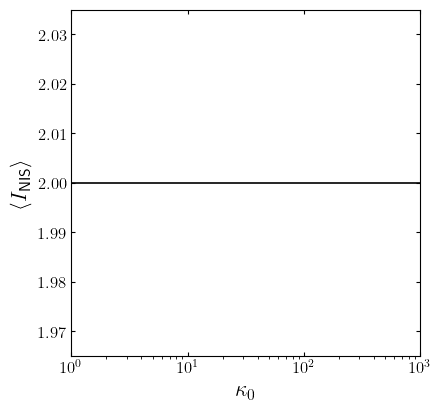

In [12]:
#Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5, 4.5))
gs = GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.fill_between(k0_nis, I_min_nis, I_max_nis, color = "k", edgecolor = None, alpha = 0.3)
ax1.plot(k0_nis, I_av_nis, "-", color = "k", lw= lc, label = r"sNFW")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
#ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax1.set_ylabel(r"$\braket{I_{\text{NIS}}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.01))
ax1.set_xlim(1, 1000)
ax1.set_ylim(1.965, 2.035)
ax1.set_xscale("log")
#ax1.set_yscale("log")

#plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

## gNFW

In [13]:
k0_max = 1000
k0_gnfw = np.concatenate((np.linspace(1, 10, 100), np.linspace(11, 100, 90), np.linspace(110, k0_max, 90)))#np.linspace(1, k0_max, points_gnfw)

n_nfw = 3
n_snfw = 3.5
n_h = 4

### NFW

In [14]:
points_eval = 10

# Here, we find the initial values, wich are obtained form those of k0_max
crs, cts = CCSolve(0.8, 2, 50, 70, 100, 10, n_nfw, k0_max)
print("Radial = ", crs)
print("Tangential = ", cts)
print("|RCC| =", np.abs(RCC(crs, n_nfw, k0_max))) # Ideally, it should be equal to zero
print("|TCC| =", np.abs(TCC(cts, n_nfw, k0_max))) # Ideally, it should be equal to zero

Radial =  1.30260960067874
Tangential =  62.55329799375744
|RCC| = 0.0
|TCC| = 0.0


In [15]:
xc2_nfw, xc1_nfw, xb_nfw, yc2_nfw = critical_points(0.8*crs, 1.2*crs, 0.8*cts, 1.2*cts, 20*cts, 1000, 5, n_nfw, k0_gnfw)

In [16]:
I_min_nfw, I_max_nfw, I_av_nfw, std_nfw, _, _ = minvariant(points_eval, xc2_nfw, xc1_nfw, xb_nfw, yc2_nfw, 1000, 5, n_nfw, k0_gnfw)

In [17]:
ind = np.where((I_max_nfw-I_min_nfw)<= 0.01*I_av_nfw)[0] # Variations of up to 1% of the mean value
print("Approximately constant range = (%.1f, %.1f)" % (np.round(k0_gnfw[ind][0],1), np.round(k0_gnfw[ind][-1],1)))

Approximately constant range = (4.5, 7.8)


In [18]:
diff = np.abs((I_max_nfw - I_min_nfw))
ind = np.where(diff == np.amin(diff))[0]
k0c_nfw = k0_gnfw[ind][0]

# For a better estimation of k0c a high density values for k0 is required
print("Smallest value for |I_max_nfw - I_min_nfw| = ", np.amin(diff))
print("k0c = ", k0c_nfw)
print("k0c (approx) = ", np.round(k0c_nfw, 1))

Smallest value for |I_max_nfw - I_min_nfw| =  0.005742412375816297
k0c =  5.909090909090909
k0c (approx) =  5.9


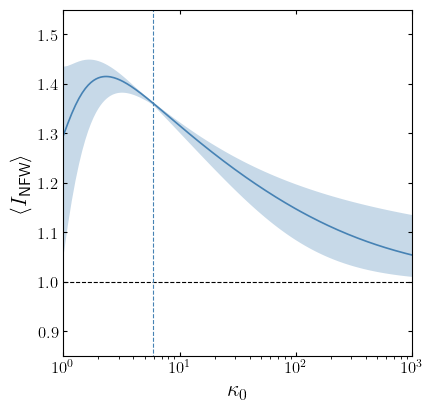

In [19]:
#Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5, 4.5))
gs = GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.fill_between(k0_gnfw, I_min_nfw, I_max_nfw, color = color_nfw, edgecolor = None, alpha = 0.3)
ax1.plot(k0_gnfw, I_av_nfw, "-", color = color_nfw, lw= lc, label = r"sNFW")

ax1.hlines(1, -10, 1100, colors='k', linestyles='--', lw =0.8)
ax1.vlines(k0c_nfw, 0, 2, colors=color_nfw, linestyles='--', lw =0.8)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
#ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax1.set_ylabel(r"$\braket{I_{\text{NFW}}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(1, 1000)
ax1.set_ylim(0.85, 1.55)
ax1.set_xscale("log")
#ax1.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

In [20]:
#Three individual cases
points_eval = 200
k0_ind = np.array([1, k0c_nfw, 100])

crs, cts = CCSolve(1e-12, 2, 1e-12, 70, 100, 10, n_nfw, 100)
print("Radial = ", crs)
print("Tangential = ", cts)
print("|RCC| =", np.abs(RCC(crs, n_nfw, 100)))
print("|TCC| =", np.abs(TCC(cts, n_nfw, 100)))

Radial =  1.1830446066026963
Tangential =  15.573317785450646
|RCC| = 0.0
|TCC| = 6.661338147750939e-16


In [21]:
xc2_nfw, xc1_nfw, xb_nfw, yc2_nfw = critical_points(0.8*crs, 1.2*crs, 0.8*cts, 1.2*cts, 20*cts, 1000, 5, n_nfw, k0_ind)

In [22]:
_, _, _, _, I_nfw, yr_nfw = minvariant(points_eval, xc2_nfw, xc1_nfw, xb_nfw, yc2_nfw, 1000, 5, n_nfw, k0_ind)

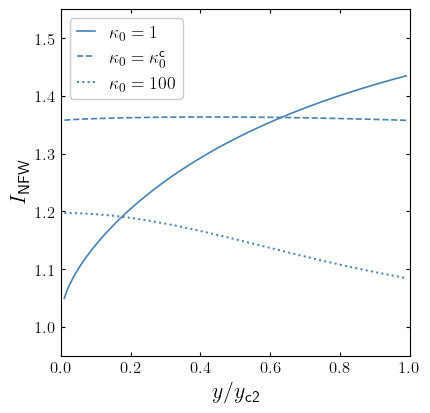

In [23]:
#Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5, 4.5))
gs = GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(yr_nfw[0], I_nfw[0], "-", color = color_nfw, lw= lc, label = r"$\kappa_0=1$")
ax1.plot(yr_nfw[1], I_nfw[1], "--", color = color_nfw, lw=lc, label = r"$\kappa_0=\kappa_0^{\text{c}}$")
ax1.plot(yr_nfw[2], I_nfw[2], ":", color = color_nfw, lw=1.2*lc, label = r"$\kappa_0=100$")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$y/y_{\text{c2}}$", fontsize=axis_fs)
#ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax1.set_ylabel(r"$I_{\text{NFW}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(0, 1)
ax1.set_ylim(0.95, 1.55)

ax1.legend(loc='upper left', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1., ncol= 1)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

### sNFW

In [24]:
points_eval = 10

# Here, we find the initial values, wich are obtained form those of k0_max
crs, cts = CCSolve(0.3, 2, 10, 50, 100, 10, n_snfw, k0_max)
print("Radial = ", crs)
print("Tangential = ", cts)
print("|RCC| =", np.abs(RCC(crs, n_snfw, k0_max))) # Ideally, it should be equal to zero
print("|TCC| =", np.abs(TCC(cts, n_snfw, k0_max))) # Ideally, it should be equal to zero

Radial =  0.8332243088524044
Tangential =  39.89811339016543
|RCC| = 0.0
|TCC| = 0.0


In [25]:
xc2_snfw, xc1_snfw, xb_snfw, yc2_snfw = critical_points(0.8*crs, 1.2*crs, 0.8*cts, 1.2*cts, 20*cts, 1000, 5, n_snfw, k0_gnfw)

In [26]:
I_min_snfw, I_max_snfw, I_av_snfw, std_snfw, _, _ = minvariant(points_eval, xc2_snfw, xc1_snfw, xb_snfw, yc2_snfw, 1000, 5, n_snfw, k0_gnfw)

In [27]:
ind = np.where((I_max_snfw - I_min_snfw) <= 0.01*I_av_snfw)[0] # Variations of up to 1% of the mean value
print("Approximately constant range = (%.1f, %.1f)" % (np.round(k0_gnfw[ind][0],1), np.round(k0_gnfw[ind][-1],1)))

Approximately constant range = (3.5, 6.0)


In [28]:
diff = np.abs((I_max_snfw - I_min_snfw))
ind = np.where(diff == np.amin(diff))[0]
k0c_snfw = k0_gnfw[ind][0]

# For a better estimation of k0c a high density values for k0 is required
print("Smallest value for |I_max_snfw - I_min_snfw| = ", np.amin(diff))
print("k0c = ", k0c_snfw)
print("k0c (approx) = ", np.round(k0c_snfw, 1))

Smallest value for |I_max_snfw - I_min_snfw| =  0.005470547975751305
k0c =  4.545454545454545
k0c (approx) =  4.5


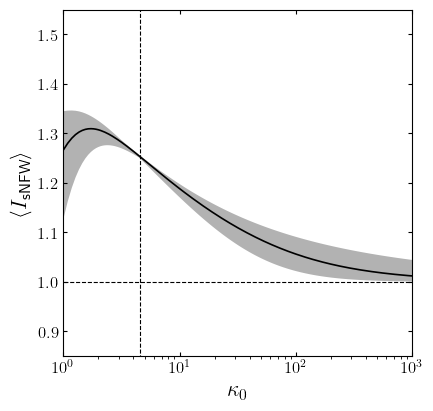

In [29]:
#Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5, 4.5))
gs = GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.fill_between(k0_gnfw, I_min_snfw, I_max_snfw, color = color_snfw, edgecolor = None, alpha = 0.3)
ax1.plot(k0_gnfw, I_av_snfw, "-", color = color_snfw, lw= lc, label = r"sNFW")

ax1.hlines(1, -10, 1100, colors='k', linestyles='--', lw =0.8)
ax1.vlines(k0c_snfw, 0, 2, colors=color_snfw, linestyles='--', lw =0.8)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
#ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(1, 1000)
ax1.set_ylim(0.85, 1.55)
ax1.set_xscale("log")
#ax1.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

In [30]:
#Three individual cases
points_eval = 200
k0_ind = np.array([1, k0c_snfw, 100])

crs, cts = CCSolve(1e-12, 2, 1e-12, 70, 100, 10, n_snfw, 100)
print("Radial = ", crs)
print("Tangential = ", cts)
print("|RCC| =", np.abs(RCC(crs, n_snfw, 100)))
print("|TCC| =", np.abs(TCC(cts, n_snfw, 100)))

Radial =  0.7865544598693616
Tangential =  11.233131713095553
|RCC| = 2.1316282072803006e-14
|TCC| = 1.1102230246251565e-16


In [31]:
xc2_snfw, xc1_snfw, xb_snfw, yc2_snfw = critical_points(0.8*crs, 1.2*crs, 0.8*cts, 1.2*cts, 20*cts, 1000, 5, n_snfw, k0_ind)

In [32]:
_, _, _, _, I_snfw, yr_snfw = minvariant(points_eval, xc2_snfw, xc1_snfw, xb_snfw, yc2_snfw, 1000, 5, n_snfw, k0_ind)

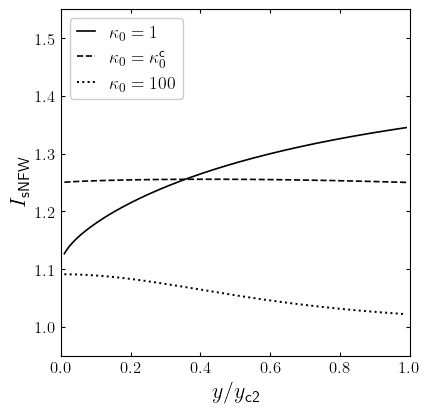

In [33]:
#Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5, 4.5))
gs = GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(yr_snfw[0], I_snfw[0], "-", color = color_snfw, lw= lc, label = r"$\kappa_0=1$")
ax1.plot(yr_snfw[1], I_snfw[1], "--", color = color_snfw, lw=lc, label = r"$\kappa_0=\kappa_0^{\text{c}}$")
ax1.plot(yr_snfw[2], I_snfw[2], ":", color = color_snfw, lw=1.2*lc, label = r"$\kappa_0=100$")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$y/y_{\text{c2}}$", fontsize=axis_fs)
#ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax1.set_ylabel(r"$I_{\text{sNFW}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(0, 1)
ax1.set_ylim(0.95, 1.55)

ax1.legend(loc='upper left', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1., ncol= 1)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

### Hernquist

In [34]:
points_eval = 10

# Here, we find the initial values, wich are obtained form those of k0_max
crs, cts = CCSolve(0.3, 2, 20, 50, 100, 10, n_h, k0_max)
print("Radial = ", crs)
print("Tangential = ", cts)
print("|RCC| =", np.abs(RCC(crs, n_h, k0_max)))# Ideally, it should be equal to zero
print("|TCC| =", np.abs(TCC(cts, n_h, k0_max)))# Ideally, it should be equal to zero

Radial =  0.6104963788777352
Tangential =  32.80820479131887
|RCC| = 0.0
|TCC| = 0.0


In [35]:
xc2_h, xc1_h, xb_h, yc2_h = critical_points(0.8*crs, 1.2*crs, 0.8*cts, 1.2*cts, 20*cts, 1000, 5, n_h, k0_gnfw)

In [36]:
I_min_h, I_max_h, I_av_h, std_h, _, _ = minvariant(points_eval, xc2_h, xc1_h, xb_h, yc2_h, 1000, 5, n_h, k0_gnfw)

In [37]:
ind = np.where((I_max_h - I_min_h) <= 0.01*I_av_h)[0] # Variations of up to 1% of the mean value
print("Approximately constant range = (%.1f, %.1f)" % (np.round(k0_gnfw[ind][0],1), np.round(k0_gnfw[ind][-1],1)))

Approximately constant range = (2.4, 4.3)


In [38]:
diff = np.abs((I_max_h - I_min_h))
ind = np.where(diff == np.amin(diff))[0]
k0c_h = k0_gnfw[ind][0]

# For a better estimation of k0c a high density values for k0 is required
print("Smallest value for |I_max_h - I_min_h| = ", np.amin(diff))
print("k0c = ", k0c_h)
print("k0c (approx) = ", np.round(k0c_h, 1))

Smallest value for |I_max_h - I_min_h| =  0.005072133918518906
k0c =  3.090909090909091
k0c (approx) =  3.1


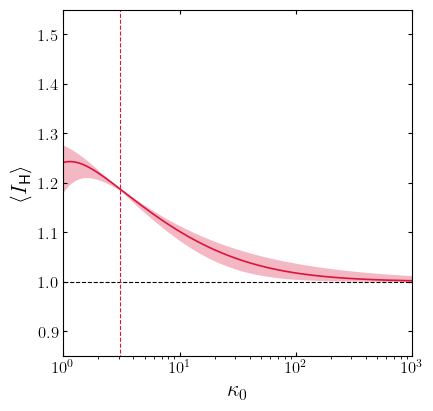

In [39]:
#Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5, 4.5))
gs = GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.fill_between(k0_gnfw, I_min_h, I_max_h, color = color_h, edgecolor = None, alpha = 0.3)
ax1.plot(k0_gnfw, I_av_h, "-", color = color_h, lw= lc, label = r"sNFW")

ax1.hlines(1, -10, 1100, colors='k', linestyles='--', lw =0.8)
ax1.vlines(k0c_h, 0, 2, colors=color_h, linestyles='--', lw =0.8)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
#ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax1.set_ylabel(r"$\braket{I_{\text{H}}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(1, 1000)
ax1.set_ylim(0.85, 1.55)
ax1.set_xscale("log")
#ax1.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

In [40]:
#Three individual cases
points_eval = 200
k0_ind = np.array([1, k0c_h, 100])

crs, cts = CCSolve(0.3, 2, 5, 50, 100, 10, n_h, 100)
print("Radial = ", crs)
print("Tangential = ", cts)
print("|RCC| =", np.abs(RCC(crs, n_h, 100)))
print("|TCC| =", np.abs(TCC(cts, n_h, 100)))

Radial =  0.5902260265906067
Tangential =  9.844389178643834
|RCC| = 0.0
|TCC| = 0.0


In [41]:
xc2_h, xc1_h, xb_h, yc2_h = critical_points(0.8*crs, 1.2*crs, 0.8*cts, 1.2*cts, 20*cts, 1000, 5, n_h, k0_ind)

In [42]:
_, _, _, _, I_h, yr_h = minvariant(points_eval, xc2_h, xc1_h, xb_h, yc2_h, 1000, 5, n_h, k0_ind)

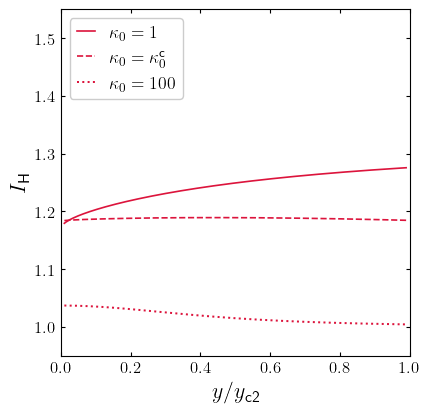

In [43]:
#Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5, 4.5))
gs = GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(yr_h[0], I_h[0], "-", color = color_h, lw= lc, label = r"$\kappa_0=1$")
ax1.plot(yr_h[1], I_h[1], "--", color = color_h, lw=lc, label = r"$\kappa_0=\kappa_0^{\text{c}}$")
ax1.plot(yr_h[2], I_h[2], ":", color = color_h, lw=1.2*lc, label = r"$\kappa_0=100$")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$y/y_{\text{c2}}$", fontsize=axis_fs)
#ax1.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax1.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(0, 1)
ax1.set_ylim(0.95, 1.55)

ax1.legend(loc='upper left', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1., ncol= 1)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

## All in one

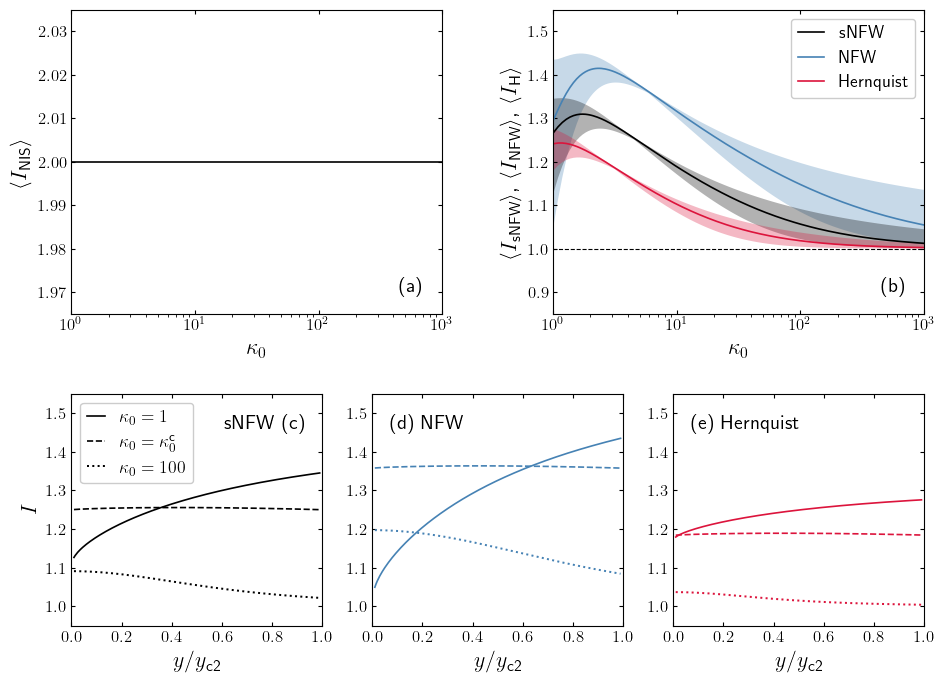

In [44]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
ls = 3
lc = 1.2

colortext = "white"
color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(11, 8))
#fig.suptitle(r"Controlling subplot sizes with width_ratios and height_ratios")

#ges = GridSpec(2, 2,hspace=0.3, wspace=0.3)
gs1 = GridSpec(1, 2, bottom = 0.5, wspace = 0.3, hspace = 0.3)
ax1 = fig.add_subplot(gs1[0,0])
ax2 = fig.add_subplot(gs1[0,1])

gs2 = GridSpec(1, 3, top = 0.4, hspace = 0.2, wspace = 0.2)
ax3 = fig.add_subplot(gs2[0, 0])
ax4 = fig.add_subplot(gs2[0, 1])
ax5 = fig.add_subplot(gs2[0, 2])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

# Panel (a)
ax1.fill_between(k0_nis, I_min_nis, I_max_nis, color = "k", edgecolor = None, alpha = 0.3)
#ax1.errorbar(k0_nis, I_av_nis, yerr=std_nis, fmt='o', color = "k",  ms = 3)
ax1.plot(k0_nis, I_av_nis, "-", color = "k", lw=lc)

# Panel (b)
ax2.fill_between(k0_gnfw, I_min_nfw, I_max_nfw, color = color_nfw, edgecolor = None, alpha = 0.3)
ax2.fill_between(k0_gnfw, I_min_snfw, I_max_snfw, color = color_snfw, edgecolor = None, alpha = 0.3)
ax2.fill_between(k0_gnfw, I_min_h, I_max_h, color = color_h, edgecolor = None, alpha = 0.3)
ax2.plot(k0_gnfw, I_av_snfw, "-", color = color_snfw, lw= lc, label = r"sNFW")
ax2.plot(k0_gnfw, I_av_nfw, "-", color = color_nfw, lw=lc, label = r"NFW")
ax2.plot(k0_gnfw, I_av_h, "-", color = color_h, lw=lc, label = r"Hernquist")
ax2.hlines(1, -10, 1100, colors='k', linestyles='--', lw =0.8)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

# Panel (c)
ax3.plot(yr_snfw[0], I_snfw[0], "-", color = color_snfw, lw= lc, label = r"$\kappa_0=1$")
ax3.plot(yr_snfw[1], I_snfw[1], "--", color = color_snfw, lw=lc, label = r"$\kappa_0=\kappa_0^{\text{c}}$")
ax3.plot(yr_snfw[2], I_snfw[2], ":", color = color_snfw, lw=1.2*lc, label = r"$\kappa_0=100$")

# Panel (d)
ax4.plot(yr_nfw[0], I_nfw[0], "-", color = color_nfw, lw= lc, label = r"NFW")
ax4.plot(yr_nfw[1], I_nfw[1], "--", color = color_nfw, lw=lc)
ax4.plot(yr_nfw[2], I_nfw[2], ":", color = color_nfw, lw=1.2*lc)

# Panel (e)
ax5.plot(yr_h[0], I_h[0], "-", color = color_h, lw= lc, label = r"Hernquist")
ax5.plot(yr_h[1], I_h[1], "--", color = color_h, lw=lc)
ax5.plot(yr_h[2], I_h[2], ":", color = color_h, lw=1.2*lc)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
ax1.set_ylabel(r"$\braket{I_{\text{NIS}}}$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.01))
ax1.set_xlim(1, 1000)
ax1.set_ylim(1.965, 2.035)
ax1.set_xscale("log")
#ax1.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax2.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
#ax2.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax2.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax2.set_xlim(1, 1000)
ax2.set_ylim(0.85, 1.55)
ax2.set_xscale("log")
#ax2.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax3.set_xlabel(r"$y/y_{\text{c2}}$", fontsize=axis_fs)
#ax3.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
ax3.set_ylabel(r"$I$", fontsize=axis_fs)
#ax3.set_title(r"$x$", fontsize=axis_fs)
ax3.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax3.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax3.set_xlim(0, 1)
ax3.set_ylim(0.95, 1.55)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax4.set_xlabel(r"$y/y_{\text{c2}}$", fontsize=axis_fs)
#ax4.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
#ax4.set_ylabel(r"$I_{\text{sNFW}}$,\quad $I_{\text{NFW}}$, \quad$I_{\text{H}}$", fontsize=axis_fs)
#ax4.set_title(r"$x$", fontsize=axis_fs)
ax4.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax4.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax4.set_xlim(0, 1)
ax4.set_ylim(0.95, 1.55)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax5.set_xlabel(r"$y/y_{\text{c2}}$", fontsize=axis_fs)
#ax5.set_ylabel(r"$\braket{I_{\text{sNFW}}}$, $\braket{I_{\text{NFW}}}$, $\braket{I_{\text{H}}}$", fontsize=axis_fs)
#ax5.set_ylabel(r"$I_{\text{sNFW}}$,\quad $I_{\text{NFW}}$, \quad$I_{\text{H}}$", fontsize=axis_fs)
#ax5.set_title(r"$x$", fontsize=axis_fs)
ax5.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax5.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax5.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax5.set_xlim(0, 1)
ax5.set_ylim(0.95, 1.55)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Text and legends
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.text(450, 1.97, r"(a)", fontsize = 0.9*axis_fs)
ax2.text(450, 0.9, r"(b)", fontsize = 0.9*axis_fs)
ax3.text(0.93, 1.46, r"sNFW (c)",  horizontalalignment="right", fontsize = 0.9*axis_fs)
ax4.text(0.07, 1.46, r"(d) NFW", fontsize = 0.9*axis_fs)
ax5.text(0.07, 1.46, r"(e) Hernquist", fontsize = 0.9*axis_fs)

ax2.legend(loc='upper right', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5, ncol= 1)
ax3.legend(loc='upper left', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1., ncol= 1)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

plt.savefig("m_invariant.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()